**--------------------------------------------------------Week07-Task01-Loan Data Analysis----------------------------------------------------------**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**1.Load the dataset using pd.read csv. How many rows and columns are in the dataset?
List the column names.**

In [ ]:
df = pd.read_csv('loan_data.csv')

In [ ]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [ ]:
print("No of Rows: ",df.shape[0])
print("No of Columns: ",df.shape[1])

No of Rows:  9578
No of Columns:  14


In [ ]:
cols = [col for col in df.columns]
cols

['credit.policy',
 'purpose',
 'int.rate',
 'installment',
 'log.annual.inc',
 'dti',
 'fico',
 'days.with.cr.line',
 'revol.bal',
 'revol.util',
 'inq.last.6mths',
 'delinq.2yrs',
 'pub.rec',
 'not.fully.paid']

In [ ]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


**2.Identify and confirm there are no missing values.**

Why is this important for model training?

Missing values can confuse the model, reduce accuracy, and cause errors in training. Handling them ensures the model learns from complete and reliable data.


In [ ]:
df.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [ ]:
df.duplicated().sum()

np.int64(0)

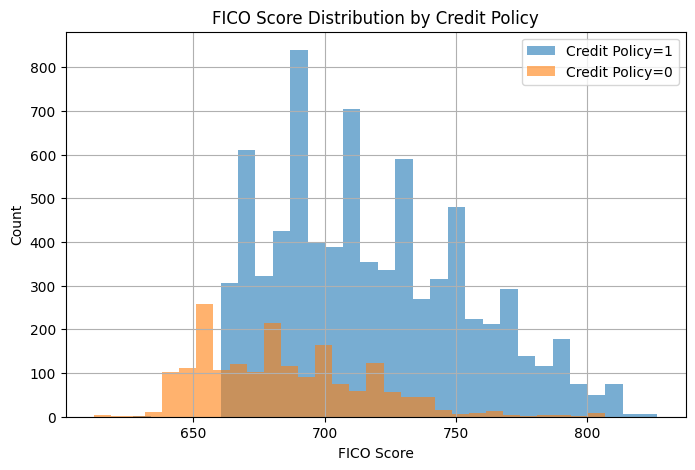

In [ ]:
plt.figure(figsize=(8,5))
df[df['credit.policy']==1]['fico'].hist(alpha=0.6, bins=30, label='Credit Policy=1')
df[df['credit.policy']==0]['fico'].hist(alpha=0.6, bins=30, label='Credit Policy=0')
plt.xlabel("FICO Score")
plt.ylabel("Count")
plt.legend()
plt.title("FICO Score Distribution by Credit Policy")
plt.show()


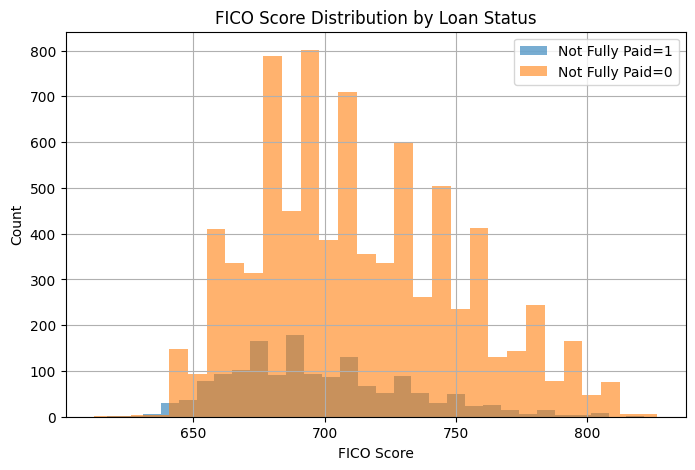

In [ ]:

# 2. Histogram of FICO scores by not.fully.paid
plt.figure(figsize=(8,5))
df[df['not.fully.paid']==1]['fico'].hist(alpha=0.6, bins=30, label='Not Fully Paid=1')
df[df['not.fully.paid']==0]['fico'].hist(alpha=0.6, bins=30, label='Not Fully Paid=0')
plt.xlabel("FICO Score")
plt.ylabel("Count")
plt.legend()
plt.title("FICO Score Distribution by Loan Status")
plt.show()

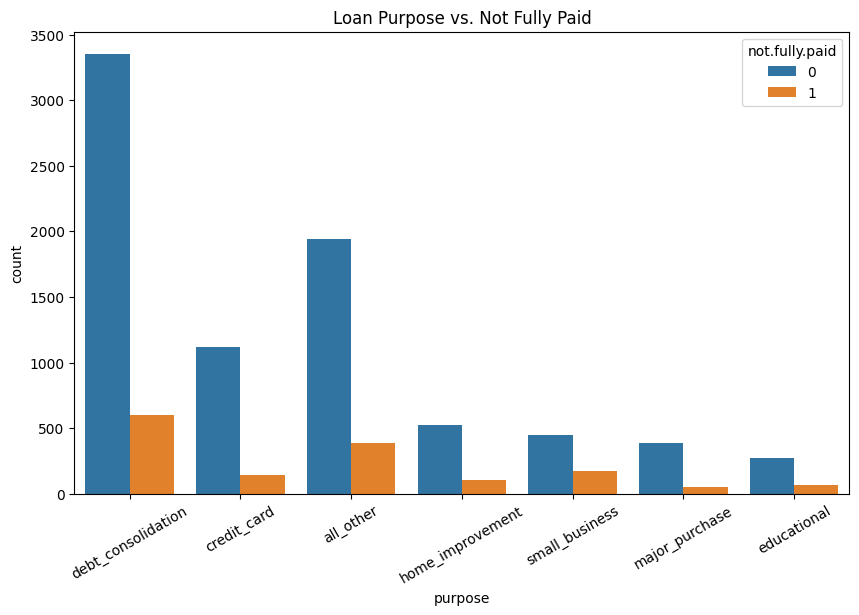

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='purpose', hue='not.fully.paid', data=df)
plt.xticks(rotation=30)
plt.title("Loan Purpose vs. Not Fully Paid")
plt.show()

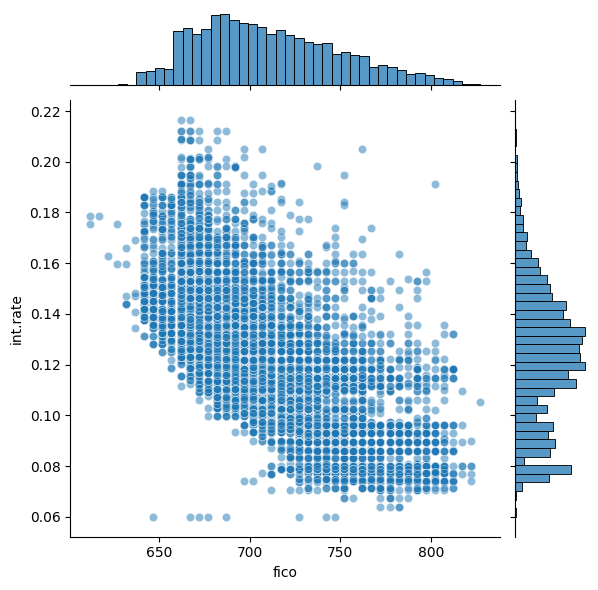

In [ ]:
sns.jointplot(x='fico', y='int.rate', data=df, kind='scatter', alpha=0.5)
plt.show()

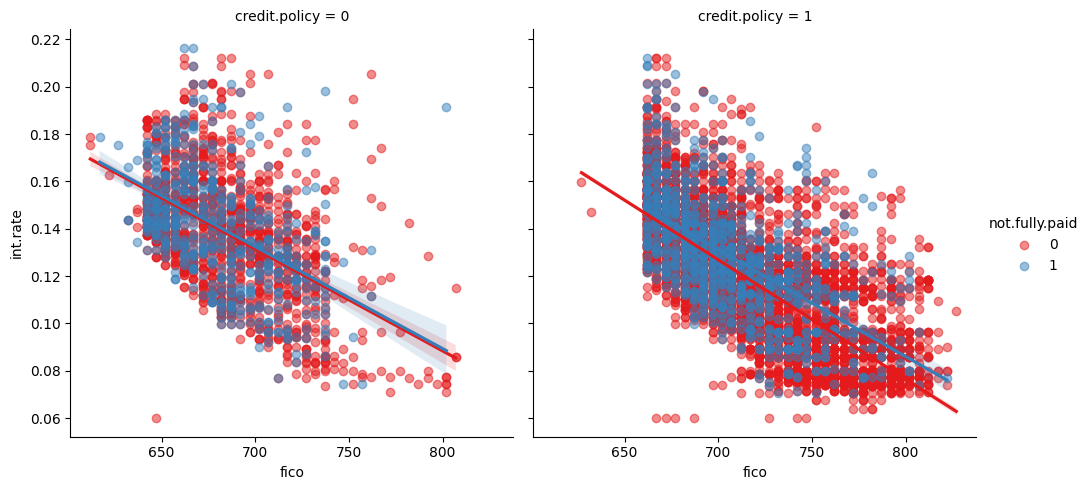

In [ ]:
sns.lmplot(x='fico', y='int.rate', data=df, hue='not.fully.paid', col='credit.policy',
           palette='Set1', scatter_kws={'alpha':0.5})
plt.show()

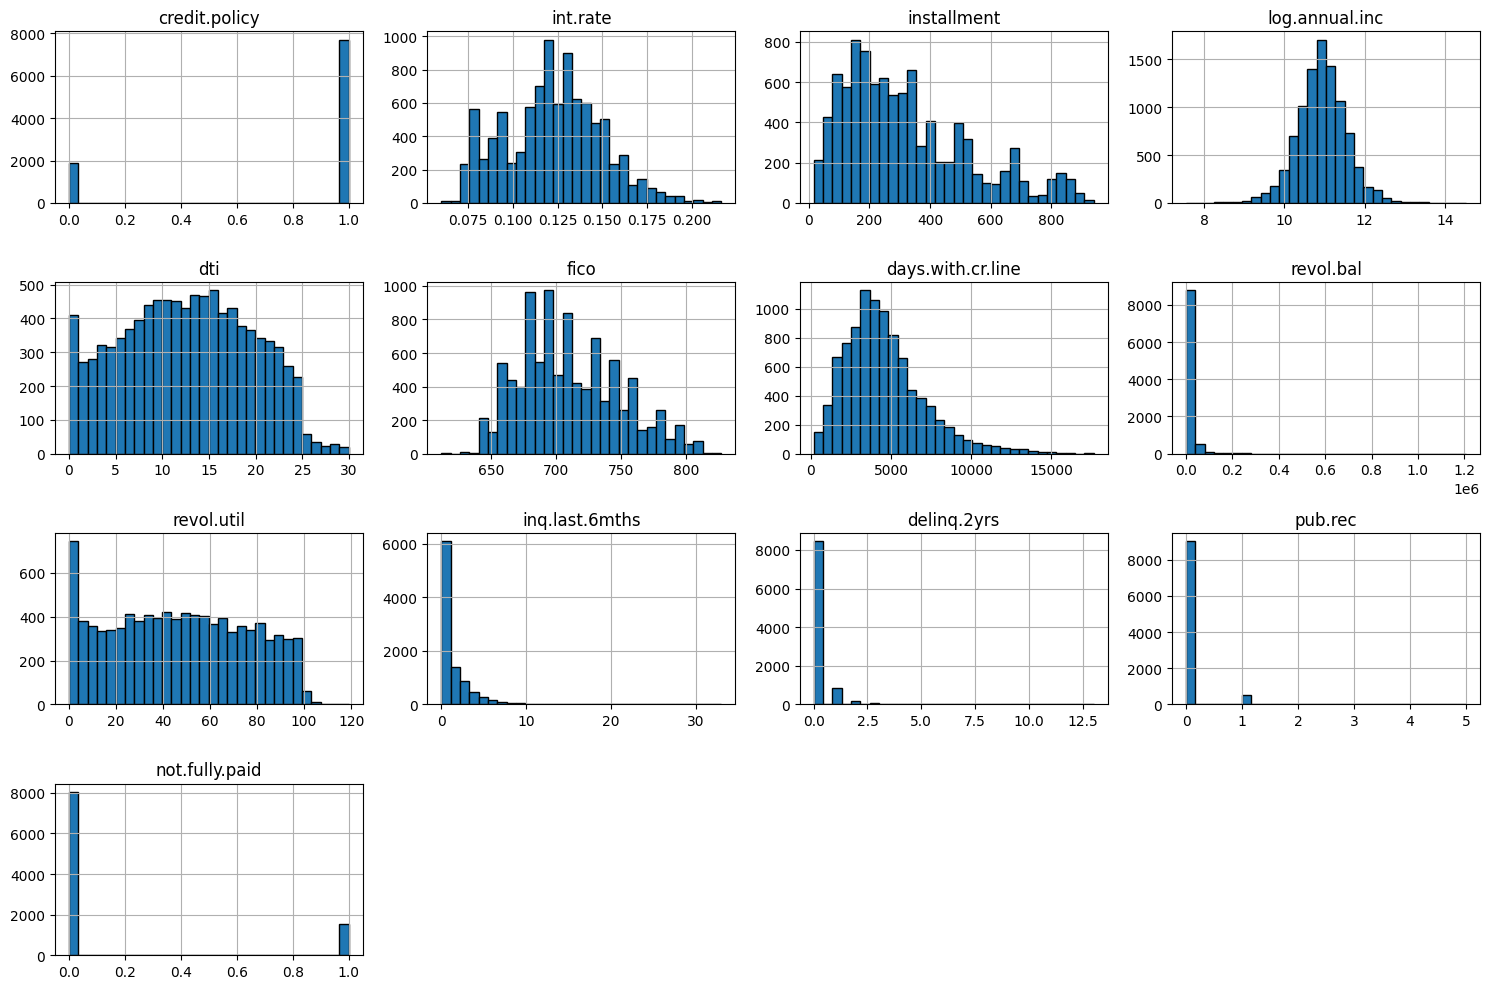

In [ ]:
df.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()

In [ ]:
df['purpose']

,purpose
0,debt_consolidation
1,credit_card
2,debt_consolidation
3,debt_consolidation
4,credit_card
...,...
9573,all_other
9574,all_other
9575,debt_consolidation
9576,home_improvement


<Axes: ylabel='count'>

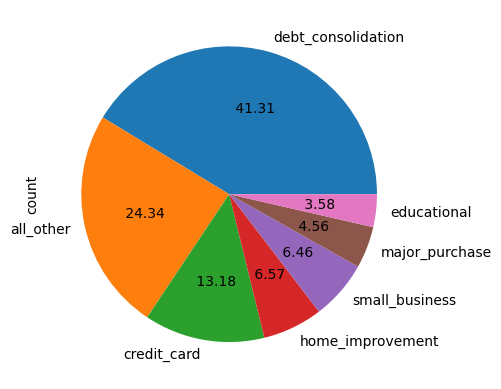

In [ ]:
df['purpose'].value_counts().plot(kind='pie', autopct='% .2f')

**3.Convert the purpose column to dummy variables. How many new columns were added,
and why was drop first=True used?**

Why use drop='first'? → To prevent the dummy variable trap (perfect multicollinearity), which can confuse regression-based models.


In [ ]:
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,3957
all_other,2331
credit_card,1262
home_improvement,629
small_business,619
major_purchase,437
educational,343


In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first',sparse_output=False )

purpose_encoded = ohe.fit_transform(df[['purpose']])

purpose_df = pd.DataFrame(purpose_encoded, columns=ohe.get_feature_names_out(['purpose']))

# Concatenate with original dataset (dropping old purpose column if needed)
df_new = pd.concat([df.drop('purpose', axis=1), purpose_df], axis=1)

print("New shape:", df_new.shape)
print("New columns added:", purpose_df.shape[1])


New shape: (9578, 19)
New columns added: 6


In [ ]:
df_new.head(5)

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_new['not.fully.paid'].value_counts()

,count
not.fully.paid,
0,8045
1,1533


<Axes: ylabel='count'>

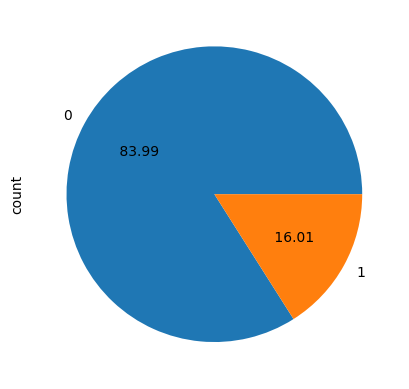

In [ ]:
df_new['not.fully.paid'].value_counts().plot(kind='pie', autopct='% .2f')

Correlation Matrix

In [ ]:
df_new.corr()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
credit.policy,1.000000,-0.294089,0.058770,0.034906,-0.090901,0.348319,0.099026,-0.187518,-0.104095,-0.535511,-0.076318,-0.054243,-0.158119,0.003216,0.020193,-0.031346,0.006036,0.024281,-0.003511
int.rate,-0.294089,1.000000,0.276140,0.056383,0.220006,-0.714821,-0.124022,0.092527,0.464837,0.202780,0.156079,0.098162,0.159552,-0.042109,0.123607,-0.019618,-0.050697,-0.068978,0.151247
installment,0.058770,0.276140,1.000000,0.448102,0.050202,0.086039,0.183297,0.233625,0.081356,-0.010419,-0.004368,-0.032760,0.049955,0.000774,0.161658,-0.094510,0.023024,-0.079836,0.145654
log.annual.inc,0.034906,0.056383,0.448102,1.000000,-0.054065,0.114576,0.336896,0.372140,0.054881,0.029171,0.029203,0.016506,-0.033439,0.072942,-0.026214,-0.119799,0.116375,-0.031020,0.091540
dti,-0.090901,0.220006,0.050202,-0.054065,1.000000,-0.241191,0.060101,0.188748,0.337109,0.029189,-0.021792,0.006209,0.037362,0.084476,0.179149,-0.035325,-0.092788,-0.077719,-0.069245
fico,0.348319,-0.714821,0.086039,0.114576,-0.241191,1.000000,0.263880,-0.015553,-0.541289,-0.185293,-0.216340,-0.147592,-0.149666,-0.012512,-0.154132,-0.013012,0.097474,0.067129,0.063292
days.with.cr.line,0.099026,-0.124022,0.183297,0.336896,0.060101,0.263880,1.000000,0.229344,-0.024239,-0.041736,0.081374,0.071826,-0.029237,0.046220,-0.009318,-0.042621,0.068087,-0.020561,0.034883
revol.bal,-0.187518,0.092527,0.233625,0.372140,0.188748,-0.015553,0.229344,1.000000,0.203779,0.022394,-0.033243,-0.031010,0.053699,0.072316,0.005785,-0.034743,0.003258,-0.062395,0.083069
revol.util,-0.104095,0.464837,0.081356,0.054881,0.337109,-0.541289,-0.024239,0.203779,1.000000,-0.013880,-0.042740,0.066717,0.082088,0.091321,0.211869,-0.053128,-0.114449,-0.108079,-0.060962
inq.last.6mths,-0.535511,0.202780,-0.010419,0.029171,0.029189,-0.185293,-0.041736,0.022394,-0.013880,1.000000,0.021245,0.072673,0.149452,-0.033640,-0.044240,0.024243,0.043827,-0.001445,0.042567


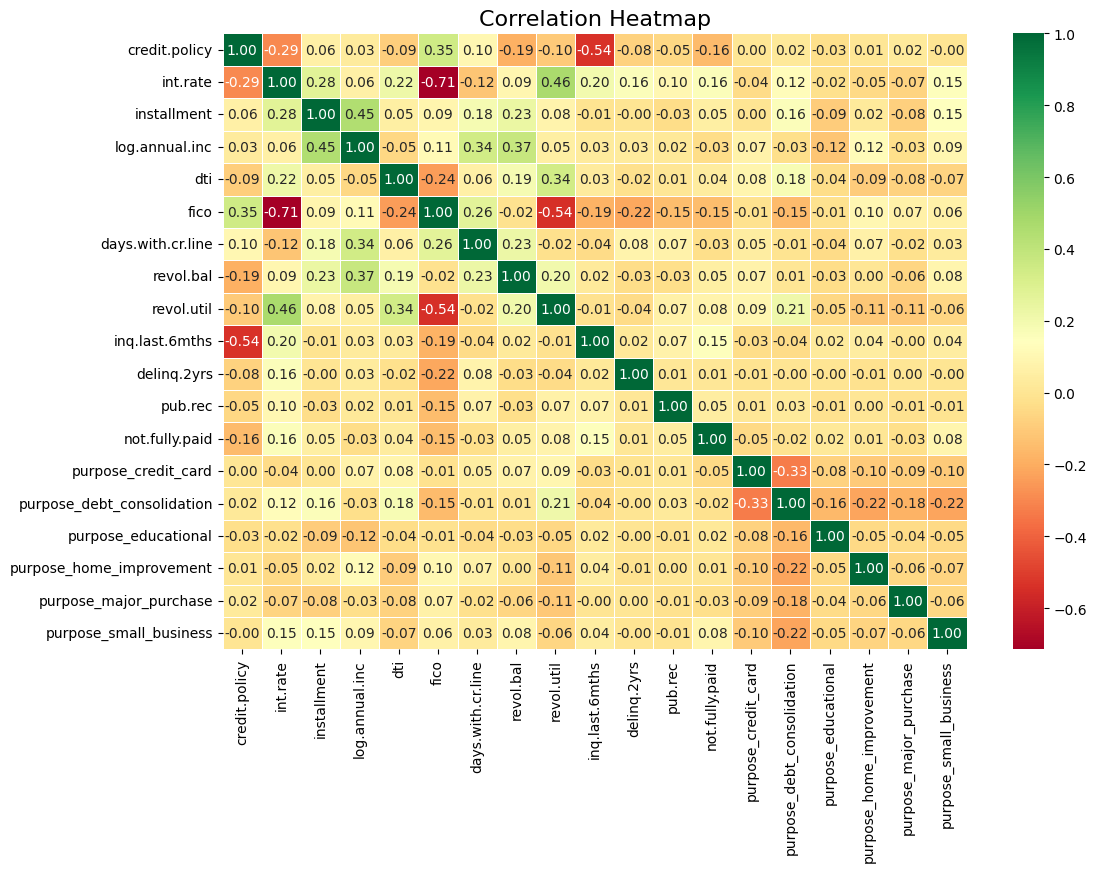

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_new.corr(),
            cmap="RdYlGn",      # green-yellow-red
            annot=True,         # show correlation values
            fmt=".2f",          # 2 decimal places
            linewidths=0.5,     # grid lines
            cbar=True)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               9578 non-null   int64  
 1   int.rate                    9578 non-null   float64
 2   installment                 9578 non-null   float64
 3   log.annual.inc              9578 non-null   float64
 4   dti                         9578 non-null   float64
 5   fico                        9578 non-null   int64  
 6   days.with.cr.line           9578 non-null   float64
 7   revol.bal                   9578 non-null   int64  
 8   revol.util                  9578 non-null   float64
 9   inq.last.6mths              9578 non-null   int64  
 10  delinq.2yrs                 9578 non-null   int64  
 11  pub.rec                     9578 non-null   int64  
 12  not.fully.paid              9578 non-null   int64  
 13  purpose_credit_card         9578 

In [ ]:
X = df_new.drop(columns=['not.fully.paid'])

y = df_new['not.fully.paid']

In [ ]:
X.shape

(9578, 18)

In [ ]:
y.shape

(9578,)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)


In [ ]:
X_res.shape

(16090, 18)

In [ ]:
y_res.shape

(16090,)

**4.Split the dataset into training and test sets. What are the sizes of these sets?**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

In [ ]:
print(f"Training X: {X_train.shape}")
print(f"Test X: {X_test.shape}")
print(f"Training y: {y_train.shape}")
print(f"Test y: {y_test.shape}")

Training X: (12872, 18)
Test X: (3218, 18)
Training y: (12872,)
Test y: (3218,)


In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

**5.Train Decision Tree and Random Forest models. Report their accuracy, precision, recall,
and F1-score. Which model performed better, and why?**

Decision Tree → A single tree. It learns the training data deeply, but often overfits (memorizes noise, poor generalization).

Random Forest → An ensemble of many Decision Trees trained on different random subsets of the data and features. Their predictions are combined (majority vote).

Random Forest performs better -->
Random Forest = many weak decision trees combined into a strong model.
That’s why it usually outperforms a single Decision Tree

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix,ConfusionMatrixDisplay


Decision Tree Classifier

In [ ]:
dtree = DecisionTreeClassifier(random_state=42,class_weight='balanced')

dtree.fit(X_train, y_train)



DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_dt = dtree.predict(X_test)

In [ ]:
# ---------------- Evaluation ---------------- #
print("Decision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-Score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Performance:
Accuracy: 0.8116842759477937
Precision: 0.8001196888090963
Recall: 0.8309509011808577
F1-Score: 0.8152439024390243

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81      1609
           1       0.80      0.83      0.82      1609

    accuracy                           0.81      3218
   macro avg       0.81      0.81      0.81      3218
weighted avg       0.81      0.81      0.81      3218



In [ ]:
rforest = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rforest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_pred_rf = rforest.predict(X_test)

In [ ]:
print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Performance:
Accuracy: 0.882224984462399
Precision: 0.9386590584878745
Recall: 0.8178993163455562
F1-Score: 0.8741281966124211

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89      1609
           1       0.94      0.82      0.87      1609

    accuracy                           0.88      3218
   macro avg       0.89      0.88      0.88      3218
weighted avg       0.89      0.88      0.88      3218



**6.Generate and interpret the confusion matrix for the Random Forest model. What are the
implications of the recall score for the minority class (not.fully.paid=1)?**


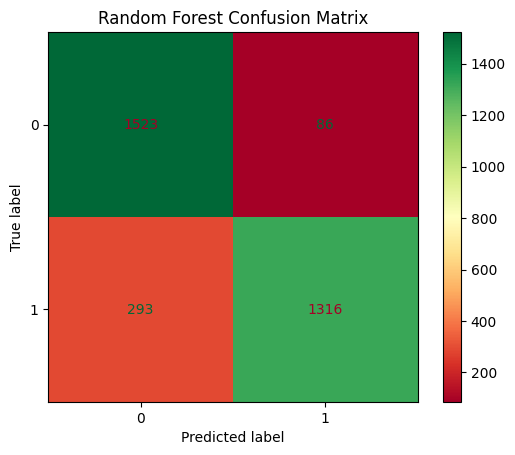

Recall for not.fully.paid=1: 0.8178993163455562


In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rforest.classes_)
disp.plot(cmap="RdYlGn")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Recall for minority class (1 = not.fully.paid)
recall_minority = recall_score(y_test, y_pred_rf, pos_label=1)
print("Recall for not.fully.paid=1:", recall_minority)

**7.Plot feature importance for the Random Forest model. Identify the top three features and
explain their significance.**

**purpose_debt_consolidation (0.1212)**

Borrowers taking loans for debt consolidation are a key signal of repayment risk.

It makes sense because people consolidating multiple debts may already be under financial stress.

**int.rate (0.0925)**

Higher interest rates usually go to higher-risk borrowers.

The model uses this to separate safer vs. riskier loans.

**credit.policy (0.0832)**

Whether the borrower meets the credit underwriting policy.

Strongly influences loan repayment likelihood, since meeting policy usually means lower risk.

/tmp/ipython-input-2107499844.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette="RdYlGn")


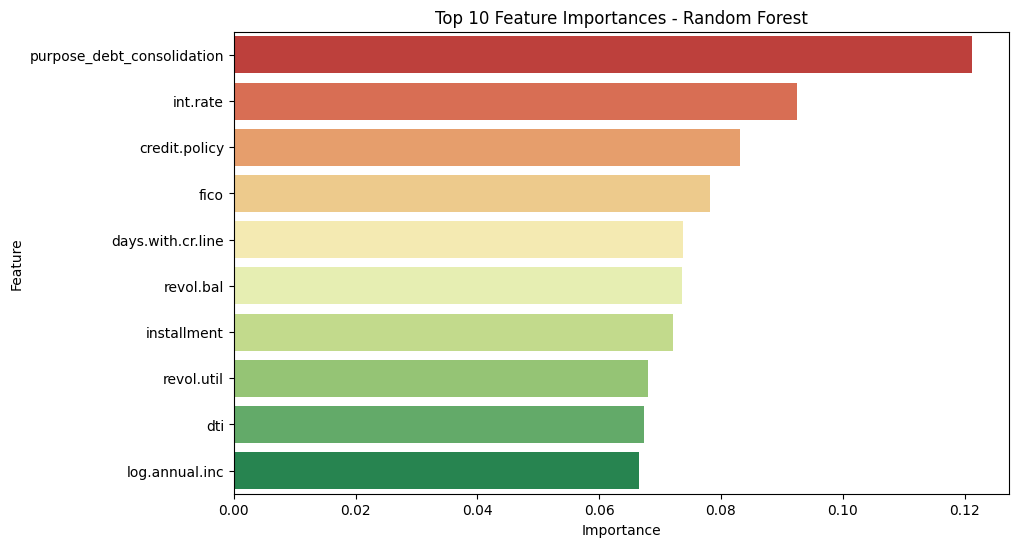

Top 3 Features:
                        Feature  Importance
13  purpose_debt_consolidation    0.121208
1                     int.rate    0.092536
0                credit.policy    0.083183


In [ ]:
# Feature importance
importances = rforest.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette="RdYlGn")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

# Top 3 features
print("Top 3 Features:\n", importance_df.head(3))

**8.Perform 5-fold cross-validation for the Random Forest model. Report the mean accuracy
and standard deviation**

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rforest, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

Cross-validation scores: [0.87067961 0.87572816 0.87995338 0.87101787 0.86674437]
Mean Accuracy: 0.8728246769411818
Standard Deviation: 0.004562556701735428


**10.Save the Random Forest model using pickle. Why is this step important for reproducibility?**


In [ ]:
import pickle

# Save model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rforest, f)

In [ ]:
# Load model back (to test)
with open("random_forest_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)